# Challenge Machine Learning Classification : Prédiction des survivants du Titanic

## Introduction


Bienvenue dans ce challenge de machine learning ! Vous allez travailler sur l'un des problèmes les plus emblématiques du domaine : la prédiction des survivants du Titanic. Ce projet vous guidera à travers toutes les étapes essentielles d'un projet de machine learning, de l'exploration détaillée des données à la création, l'amélioration et l'interprétation d'un modèle de régression logistique.

## Contexte historique


Le RMS Titanic était un paquebot britannique qui a fait naufrage dans l'océan Atlantique Nord en avril 1912 après avoir heurté un iceberg lors de son voyage inaugural de Southampton à New York. Sur les 2224 passagers et membres d'équipage, plus de 1500 ont perdu la vie, faisant de cette tragédie l'un des naufrages les plus mortels de l'histoire maritime en temps de paix.

Ce désastre a conduit à d'importantes améliorations dans les réglementations de sécurité maritime et est devenu un sujet d'étude fascinant pour les data scientists, qui cherchent à comprendre quels facteurs ont influencé les chances de survie des passagers.


## Objectif du projet


Votre mission est de développer un modèle de machine learning capable de prédire si un passager a survécu ou non au naufrage du Titanic, en vous basant sur diverses caractéristiques telles que l'âge, le sexe, la classe de billet, etc. Ce faisant, vous découvrirez des insights précieux sur les facteurs qui ont influencé la survie lors de cette tragédie historique.


## Partie 1 : Préparation et exploration approfondie des données

### 1.1 Chargement et préparation initiale des données


**Objectif** : Charger le dataset et effectuer une première inspection des données.

**Explication du code ci-dessous** :

1. Importer les bibliothèques nécessaires : pandas, numpy, matplotlib, seaborn.
2. Charger les données du Titanic depuis le lien fourni avec pandas.
3. Affichage des 10 premières lignes du DataFrame avec `head()`.
4. Utilisation de la méthode `info()` pour obtenir un aperçu global du DataFrame, y compris les types de données et les valeurs non-nulles.

**Questions de réflexion** :
- Combien y a-t-il de passagers dans ce dataset ?
- Quels types de données (numériques, catégorielles) pouvez-vous identifier ?
- Y a-t-il des colonnes avec des valeurs manquantes ? Si oui, lesquelles ?



In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns
link = "https://raw.githubusercontent.com/murpi/wilddata/master/quests/titanic_passengers.csv"
df_titanic = pd.read_csv(link)
df_titanic.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [2]:
df_titanic.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [14]:
# Réponses aux question de réflexion
# Le dataset se compose de 891 rangs et 12 colonnes réparties en 3 type (int, float, str) 
# dont 2 colonnes qui présentent des valeurs manquantes. On ne peut pas évaluer le nombre de passager. 
# Il faut plus d'analyse pour déterminer les valeurs catégorielles qui pourraient se présenter de manière numérique.

### 1.2 Analyse statistique descriptive

**Objectif** : Obtenir des statistiques descriptives pour mieux comprendre la distribution des données.

**Instructions** :

1. Analysez des statistiques descriptives des colonnes numériques.
2. Pour les colonnes catégorielles, regardez la distribution des valeurs des catégories.
3. Calculez le pourcentage global de survie.

**Questions de réflexion** :
- Quelle est la moyenne d'âge des passagers ? Et la médiane ?
- Quelle est la répartition des passagers entre les différentes classes ?
- Y a-t-il une grande différence entre la moyenne et la médiane pour certaines variables ? Si oui, que cela pourrait-il indiquer ?


In [3]:
# Analyse statistique
# L'analyse descriptive montre une moyenne d'âge de presque 30 ans avec des outliers allant de Quelques mois à 80 ans
# la mediane est de 28 ans.
df_titanic.describe(include='number').T

,count,mean,std,min,25%,50%,75%,max
PassengerId,891.0,446.000000,257.353842,1.00,223.5000,446.0000,668.5,891.0000
Survived,891.0,0.383838,0.486592,0.00,0.0000,0.0000,1.0,1.0000
Pclass,891.0,2.308642,0.836071,1.00,2.0000,3.0000,3.0,3.0000
Age,714.0,29.699118,14.526497,0.42,20.1250,28.0000,38.0,80.0000
SibSp,891.0,0.523008,1.102743,0.00,0.0000,0.0000,1.0,8.0000
Parch,891.0,0.381594,0.806057,0.00,0.0000,0.0000,0.0,6.0000
Fare,891.0,32.204208,49.693429,0.00,7.9104,14.4542,31.0,512.3292


In [4]:
# Répartition des passagers entre les différentes classes
df_titanic.Pclass.value_counts()

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

In [15]:
# Différence entre moyenne et médiane pour certaines variables => conclusions
# On distingue une variance d'environ 2 années entre la moyenne d'âge et la médiane dût aux valeurs extrèmes
# Au niveau de la répartition des classes, la mediane montre que plus de la moitier des passagers sont en 3ème classes.
# Cependant la moyenne tant plutôt vers la 2èeme classe.
# Pour le nombre de frère/soeur (SibSp) et le nombre de parent/enfant (Parch), la mediane ainsi que la valeur maximum
# montre que des valeurs extrème créer des variance avec leurs moyennes respectives.

### 1.3 Visualisation approfondie des données

**Objectif** : Créer des visualisations pour mieux comprendre les relations entre les variables et leur impact sur la survie.

**Instructions** :

1. Créez un histogramme de la distribution des âges, avec une distinction entre survivants et non-survivants.
2. Réalisez un graphique en barres montrant le taux de survie par classe de passager.
3. Faites un graphique en violon pour comparer la distribution des tarifs (Fare) entre les survivants et les non-survivants.
4. Créez une heatmap de corrélation pour toutes les variables numériques.
5. Réalisez un graphique en barres empilées pour montrer la survie en fonction du sexe et de la classe.

**Questions de réflexion** :
- Y a-t-il une différence notable dans la distribution des âges entre les survivants et les non-survivants ?
- Quelle classe de passagers semble avoir eu le meilleur taux de survie ? Le pire ?
- Pouvez-vous identifier une corrélation entre le prix du billet et les chances de survie ?
- Quelles variables semblent être les plus corrélées avec la survie ?



<Axes: xlabel='Age', ylabel='Count'>

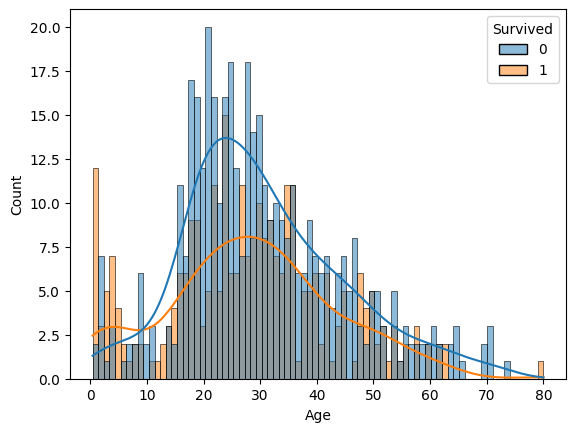

In [5]:
# histogramme de la distribution des âges, avec une distinction entre survivants et non-survivants
import matplotlib.pyplot as plt
import seaborn as sns
sns.histplot(x=df_titanic.Age, hue=df_titanic.Survived, bins= 80, kde=True)

<Axes: xlabel='Pclass', ylabel='percent'>

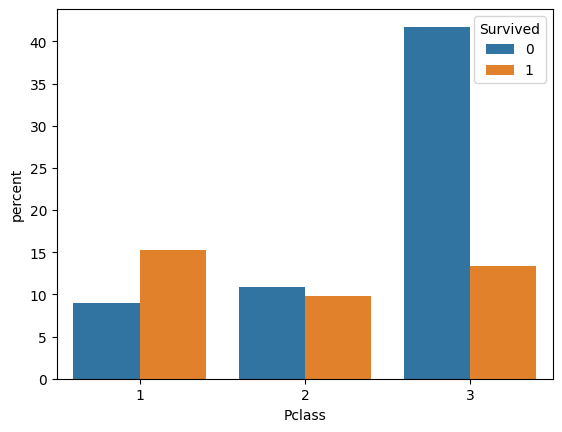

In [6]:
# graphique en barres montrant le taux de survie par classe de passager
sns.countplot(x=df_titanic.Pclass, hue=df_titanic.Survived,stat='percent')

<Axes: xlabel='Fare'>

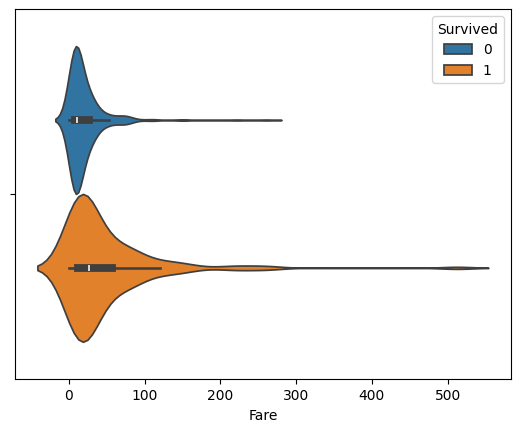

In [7]:
# graphique en violon pour comparer la distribution des tarifs (Fare)
# entre les survivants et les non-survivants
sns.violinplot(x=df_titanic.Fare, hue=df_titanic.Survived)

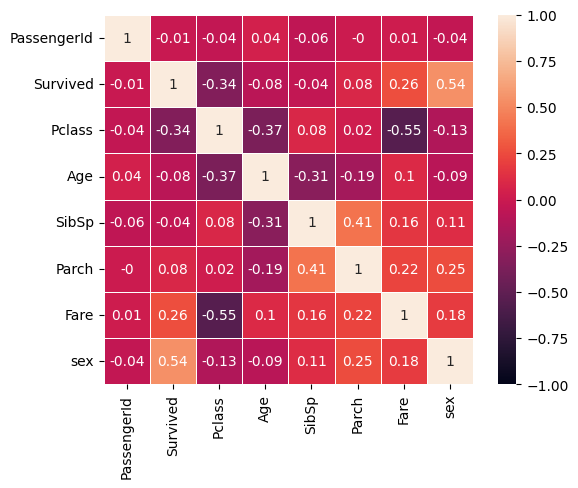

In [8]:
# heatmap de corrélation pour toutes les variables numériques
# On factorise la Serie `Sex` qui semble corrélé avec la survie des passager au regard des précédent graphique
df_titanic['sex']= df_titanic.Sex.factorize()[0]
sns.heatmap(df_titanic.select_dtypes(include='number').corr().round(2), annot=True, vmin=-1, vmax=1,linewidths=0.5, square=True)
# Après vérification on revient au jeu de données initiale
df_titanic = df_titanic.drop('sex', axis=1)

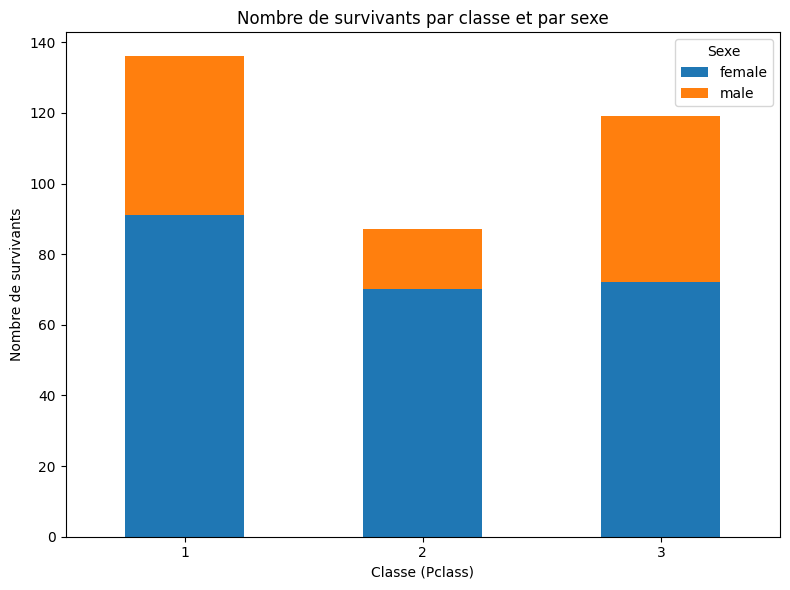

In [10]:
# graphique en barres empilées pour montrer la survie en fonction du sexe et de la classe

# On ne garde que les survivants
survivants = df_titanic[df_titanic['Survived'] == 1]

# 3 colonnes (Pclass) qui empilent le nombre de chaque sexe
pd.crosstab(survivants['Pclass'], survivants['Sex']).plot(kind='bar', stacked=True, figsize=(8, 6))

plt.title('Nombre de survivants par classe et par sexe')
plt.xlabel('Classe (Pclass)')
plt.ylabel('Nombre de survivants')
plt.legend(title='Sexe')
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

In [185]:
# Réponses aux questions de réflexion

# 1. A partir de l'histogramme de la distribution des âges, on remarque que la distribution est similaire avec
# une légère différence pour les passagers de bas âge.

# 2. A partir du graphique en barres montrant le taux de survie par classe de passager on remarque nettement que la 1ère
# classe à un taux positive de survivant contrairement à la 2ème et 3ème classes

# 3. D'après la heatmap de corrélation on voit qu'une corrélation faible existe entre le prix du billet et les 
# chances de survies. Il y a une corrélation assez net entre la classe et le prix du billet. On peut déduire que la
# corrélation entre le prix du billet et la survie est indirectement lié au fait que les classes plus aisés ont un 
# meilleur taux de survie. Privilégiés ? meilleur accès aux cannot de sauvetage ? il faudrait approfondir les recherche
# pour en savoir plus

# 4. La Serie `Sex` semble être la plus corrélé. Après factorisation des données de la Serie et l'observation de la 
# Heatmap de corrélation, il est clair que le sex est de loin la donnée la plus corrélée avec la survie des passagers,
# ensuite viens la classe (Pclass) et indirectement le prix du billet (Fare).
# Bien que l'histogramme montre une survie positive chez les enfants de bas âges, l'âge ne semble pas être en corrélation
# direct avec le taux de survie. les Valeurs extrème pourrait faussé l'observation. A étudier.

### 1.4 Analyse des valeurs manquantes

**Objectif** : Identifier et traiter les valeurs manquantes dans le dataset.

**Instructions** :

1. Comptez les valeurs manquantes dans chaque colonne.
2. Créez un graphique montrant le pourcentage de valeurs manquantes pour chaque colonne.
3. Pour la colonne 'Age', analysez si les valeurs manquantes sont distribuées aléatoirement ou s'il y a un biais.
4. Proposez et implémentez une stratégie pour gérer ces valeurs manquantes (par exemple, imputation par la moyenne, la médiane, ou une méthode plus avancée).

**Questions de réflexion** :
- Quelles colonnes ont le plus de valeurs manquantes ?
- Pourquoi certaines colonnes pourraient-elles avoir plus de valeurs manquantes que d'autres ?
- Quelle stratégie d'imputation vous semble la plus appropriée pour chaque colonne avec des valeurs manquantes ? Pourquoi ?



In [11]:
# Nombre de valeurs manquantes
df_titanic.isna().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

<Axes: >

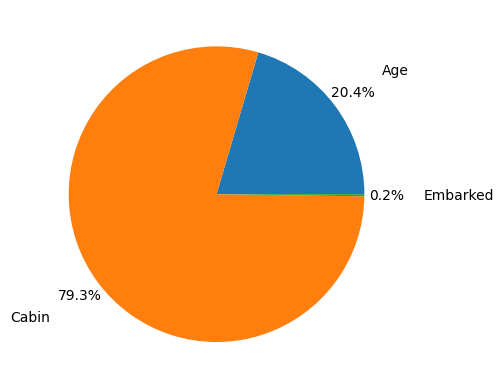

In [12]:
# graphique montrant le pourcentage de valeurs manquantes pour chaque colonne
df_titanic[['Age', 'Cabin', 'Embarked']].isna().mean().plot(kind='pie', autopct='%1.1f%%',pctdistance=1.15, labeldistance=1.4)

In [13]:
# Analyse des valeurs manquantes de la colonne "Age" 
# 177 passagers ayant une valeure manquante dans la colonne Age
# 124 hommes vs 53 femmes
# 136 dans la 3ème classe / 11 en 2èeme classe / 30 en première
# 125 non-survivants vs 52 survivants
# 137 sans frère ni soeur à bord / 40 personnes avec au moins un frère ou une soeur
# 157 sans parent ou enfant / 20 avec un/des parent(s) ou au moins un enfant
check_list = ['Sex','Pclass', 'Survived', 'Embarked', 'SibSp', 'Parch']
for check in check_list:
    print(f"=========== {check} =============")
    print(pd.crosstab(df_titanic.Age.isna(), df_titanic[check]))

=========== Sex =============
Sex    female  male
Age                
False     261   453
True       53   124
=========== Pclass =============
Pclass    1    2    3
Age                  
False   186  173  355
True     30   11  136
=========== Survived =============
Survived    0    1
Age               
False     424  290
True      125   52
=========== Embarked =============
Embarked    C   Q    S
Age                   
False     130  28  554
True       38  49   90
=========== SibSp =============
SibSp    0    1   2   3   4  5  8
Age                              
False  471  183  25  12  18  5  0
True   137   26   3   4   0  0  7
=========== Parch =============
Parch    0    1   2  3  4  5  6
Age                            
False  521  110  68  5  4  5  1
True   157    8  12  0  0  0  0


In [313]:
# Stratégie pour gérer les valeurs manquantes
# L'analyse des valeures manquantes dans la colonne Age montre que ce sont des passagers principalement masculins,
# qui provienne pour la plupart de la 3ème classe et qui ont très peu survécu. les deux tiers provienne de Southampton,
# ce qui apporte une piste nouvelle sur le type de passager provenant de cette ville. En ce qui concerne l'age on peut
# également voir que pour la grande partie ce sont des passagers qui ont embarqués seuls
# 
# 3 stratégies se propose.
   # 1ère stratégie:
        # Il est difficile de coller à la réalité et changer le dataset pourrait le dénaturé et avoir un impact sur la
        # prédiction de notre modèle. Néanmoins ne pas les changer pourrait également avoir un impact puisqu'il y a un taux 
        # élévé de passager avec des critère communs
    # 2ème stratégie:
        # D'après l'analyse des valeurs manquante, on peut créer un filtre à partir de critère défini en focntion des
        # données extraite de cette analyse. Cette approche semble être la meileur bien qu'il faille tester pour le dire,
        # nénamoins le travail pour coller à la réalité est assez conséquent. 
    # 3ème stratégie:
        # Hybride - faire une prédiction sans les valeurs puis une prédiction avec des valeurs synthétique d'après les 
        # critères de la l'analyse de la colonne Age.

# L'approche de la stratégie 2 semble ^tre la meilleur, cependant il faut ne pas prendre partie et tester toute éventualité
# donc nous partirons sur une approche hybride en testant dans un premier temps une prédiction avec un dataset netoyé des 
# valeurs manquantes.

In [314]:
# Réponses aux questions de réflexion
# 1. Les colonnes qui ont le plus de valeurs manquantes sont Age et Cabin
# 2. Il n'y a pas vraiment d'explication au manque de valeurs sur l'âge des passagers. Ce qui resssort c'est que 
# ce sont principalment des hommes à faible revenu. Peut être des travailleurs sur le bateau à qui l'âge n'était 
# pas demandé à l'embarquement ou bien à un registre mal tenu. Tout ceci ne sont qu'hyothèse et cette question 
# n'a pas vraiment de sens dans une analyse data driven.
# 3. La stratégie à été évoqué lors de l'exercice précédent.

## Partie 2 : Préparation du modèle de régression logistique

### 2.1 Sélection des features

**Instructions :**

Divisez les données en features (X) et target (y).

In [72]:
# Sélection des features pertinentes à partir de la corrélation
data = df_titanic[['Pclass', 'Sex', 'Age', 'Survived']].dropna(axis=0, ignore_index=True)
X = data[['Pclass', 'Sex', 'Age']]
y = data.Survived

### 2.2 Division des données

**Objectif** : Diviser les données en ensembles d'entraînement et de test.

**Instructions** :

1. Importez `train_test_split` de sklearn.
2. Divisez vos données en ensembles d'entraînement et de test (80% train, 20% test).
3. Utilisez `random_state=36` pour la reproductibilité.
4. Utilisez `stratify = y' pour vous assurer que la porportion de survivants est similaire dans les deux ensembles.
5. Vérifiez que la proportion de survivants est similaire dans les deux ensembles.

**Questions de réflexion** :
- Pourquoi est-il important de diviser les données en ensembles d'entraînement et de test ?
- Que se passerait-il si la proportion de survivants était très différente entre les deux ensembles ?



In [73]:
# Division des données avec train_test_split / Vérification de la distribution
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=36, stratify=y)

In [ ]:
# Réponses aux questions de réflexion
# Diviser les données permet d'évaluer honnetement le modèle sans qu'il puisse faire de prédiction sur
# un dataset sur laquel il s'est déjà entraîner, ce qui fausserait le résultat
# La proportion des survivant entre datset d'entrainement et de test est primordial pour ne pas déséquilibrer
# les données apportés au modèle

### 2.3 Préparation des features

**Objectif** : Préparer les données pour l'entraînement du modèle.

**Instructions** :

1. Utilisez `OneHotEncoder()` pour encoder les variables catégorielles.
2. Normalisez les features numériques en utilisant `StandardScaler` de sklearn.

**Questions de réflexion** :
- Pourquoi est-il important d'encoder les variables catégorielles ?
- Quels sont les avantages de la normalisation des features numériques ?
- Y a-t-il des features que vous avez décidé de ne pas inclure ? Pourquoi ?

In [74]:
# Sélection des features pertinentes
X.info()

<class 'pandas.DataFrame'>
RangeIndex: 714 entries, 0 to 713
Data columns (total 3 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Pclass  714 non-null    int64  
 1   Sex     714 non-null    str    
 2   Age     714 non-null    float64
dtypes: float64(1), int64(1), str(1)
memory usage: 20.2 KB


In [75]:
# Encodage des variables catégorielles
from sklearn.preprocessing import OneHotEncoder, StandardScaler
# Encodage
ohe = OneHotEncoder(sparse_output=False, handle_unknown="ignore")
X['Sex'] = ohe.fit_transform(X[['Sex']])

In [80]:
X.shape

(714, 3)

In [79]:
# Normalisation des features numériques avec un Standard Scaler
std = StandardScaler()
std.fit_transform(X[['Pclass', 'Age', 'Sex']])

array([[ 0.91123237, -0.53037664, -0.75905134],
       [-1.47636364,  0.57183099,  1.31743394],
       [ 0.91123237, -0.25482473,  1.31743394],
       ...,
       [-1.47636364, -0.73704057,  1.31743394],
       [-1.47636364, -0.25482473, -0.75905134],
       [ 0.91123237,  0.15850313, -0.75905134]], shape=(714, 3))

In [55]:
X

,Pclass,Sex,Age
0,3,0.0,-0.530377
1,1,1.0,0.571831
2,3,1.0,-0.254825
3,1,1.0,0.365167
4,3,0.0,0.365167
...,...,...,...
709,3,1.0,0.640719
710,2,0.0,-0.185937
711,1,1.0,-0.737041
712,1,0.0,-0.254825


In [56]:
# Division entre features et target
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.2, random_state=36, stratify=y)

In [ ]:
# Réponses aux questions de réflexion
# 1. Il est important d'encoder les valeurs catégorielle afin que le modèle puisse les traités. Le modèle ne peut 
# pas traités des chaîne de caractères et ne peut que traités des nombres.
# 2. La normalisation des features nulériques servent à mettre à une échelle plus petite tout en gardant les distances
# entre les valeurs qfin que le modèle puisse les traité plus facilement.
# La feature Pclass ne m'a pas parut essentiel parce qu'elle est de nature catégorielle et déjà sous forme numérique (1,2,3)

### 2.3 Entraînement du modèle initial

**Objectif** : Entraîner un premier modèle de régression logistique et évaluer ses performances.

**Instructions** :

1. Importez `LogisticRegression` de sklearn.
2. Instanciez un modèle de régression logistique avec `random_state=36`.
3. Entraînez le modèle sur les données d'entraînement.
4. Faites des prédictions sur les ensembles d'entraînement et de test.
5. Calculez et affichez la précision (accuracy) sur les deux ensembles.
6. Affichez la matrice de confusion et le rapport de classification pour l'ensemble de test.
7. Affichez les coefficients du modèle et interprétez-les.

**Questions de réflexion** :
- Comment interprétez-vous la différence de précision entre l'ensemble d'entraînement et l'ensemble de test ?
- Quelles features semblent avoir le plus d'impact sur la prédiction selon les coefficients du modèle ?
- Y a-t-il des signes de surapprentissage (overfitting) ou de sous-apprentissage (underfitting) ?



In [58]:
# Création et entrainement d'un modèle de régression logistique
from sklearn.linear_model import LogisticRegression
import numpy as np
model = LogisticRegression(random_state=36)

In [62]:
X.shape

(714, 3)

In [71]:
# Calcule des prédictions sur les données de test
model.fit(X, y)

ValueError: could not broadcast input array from shape (2,714) into shape (1,714)

In [ ]:
# Affichage de la précision du modèle


In [ ]:
# Affichage de la matrice de confusion
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay


In [ ]:
# Affichage du rapport de classification
from sklearn.metrics import classification_report


In [ ]:
# Coefficients du modèle


In [ ]:
# Interprétation des coefficients
"""

"""

In [ ]:
# Y a-t-il surapprentissage ou sous-apprentissage ?
"""

"""

## Conclusion et réflexions finales

1. Résumez les principales découvertes de votre analyse.
2. Quels facteurs semblent avoir le plus influencé la survie sur le Titanic ?
3. Quelles sont les limites de votre analyse et comment pourriez-vous l'améliorer ?
4. Si vous deviez conseiller quelqu'un pour augmenter ses chances de survie sur le Titanic, que lui diriez-vous basé sur votre analyse ?
5. Comment les techniques que vous avez apprises dans ce projet pourraient-elles être appliquées à d'autres problèmes de la vie réelle ?



In [ ]:
"""

"""